In [1]:
import sys
sys.path.append('../scripts')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from eda_and_split import AirQualityEDA, TimeSeriesSplit

In [2]:
# --- Load cleaned Boston and NewYork data ---
boston_df = pd.read_csv('../data/cleaned/boston_cleaned.csv')
newyork_df = pd.read_csv('../data/cleaned/newyork_cleaned.csv')


--- Basic Information: Boston ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122768 entries, 0 to 122767
Data columns (total 34 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   SensorID     122768 non-null  object        
 1   time         122768 non-null  int64         
 2   latitude     122768 non-null  float64       
 3   longitude    122768 non-null  float64       
 4   bin0         122768 non-null  int64         
 5   bin1         122768 non-null  int64         
 6   bin10        122768 non-null  int64         
 7   bin11        122768 non-null  int64         
 8   bin12        122768 non-null  int64         
 9   bin13        122768 non-null  int64         
 10  bin14        122768 non-null  int64         
 11  bin15        122768 non-null  int64         
 12  bin16        122768 non-null  int64         
 13  bin17        122768 non-null  int64         
 14  bin18        122768 non-null  int64         
 15 

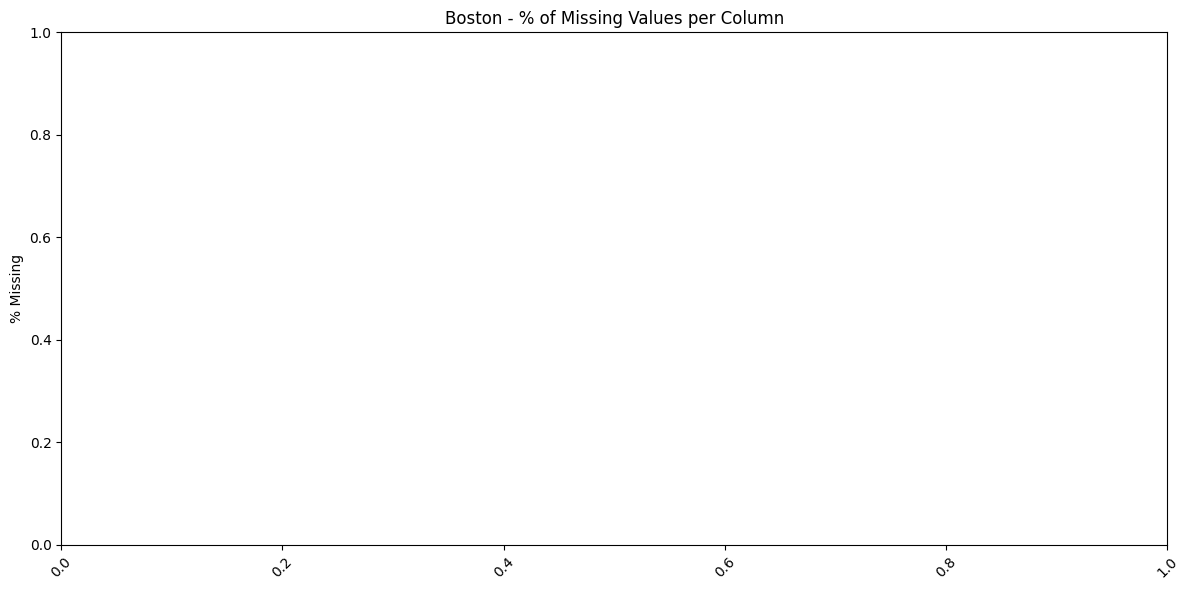

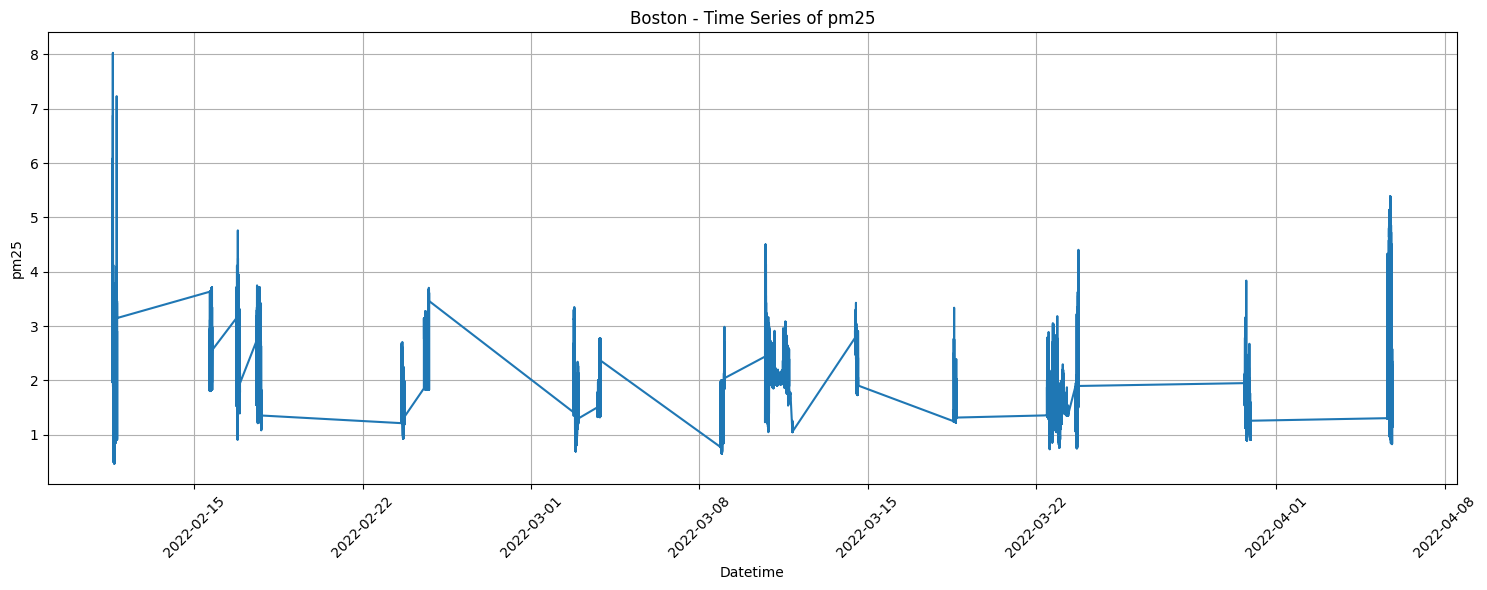

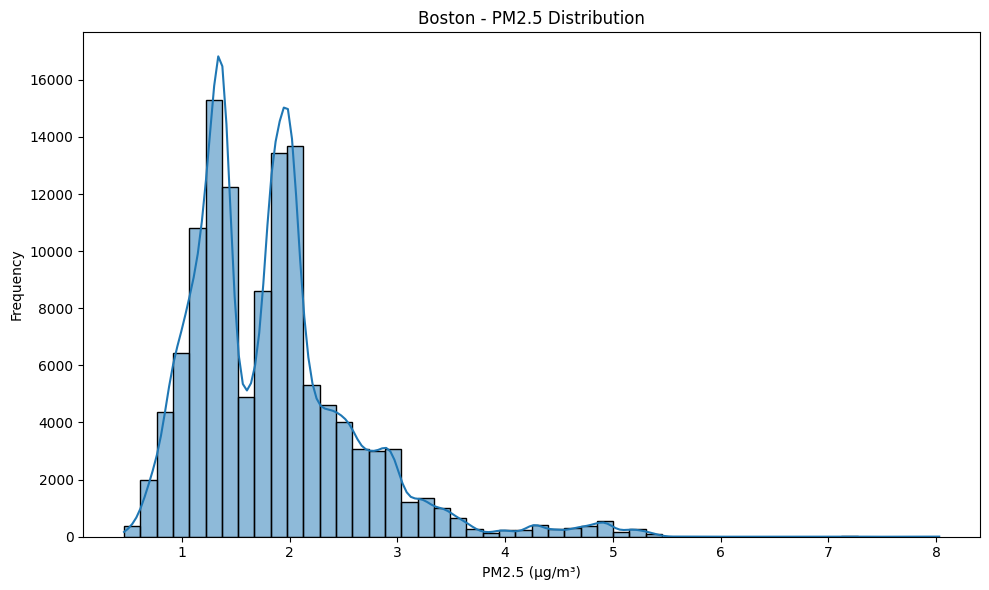


--- Geohash PM2.5 Trends: Boston ---


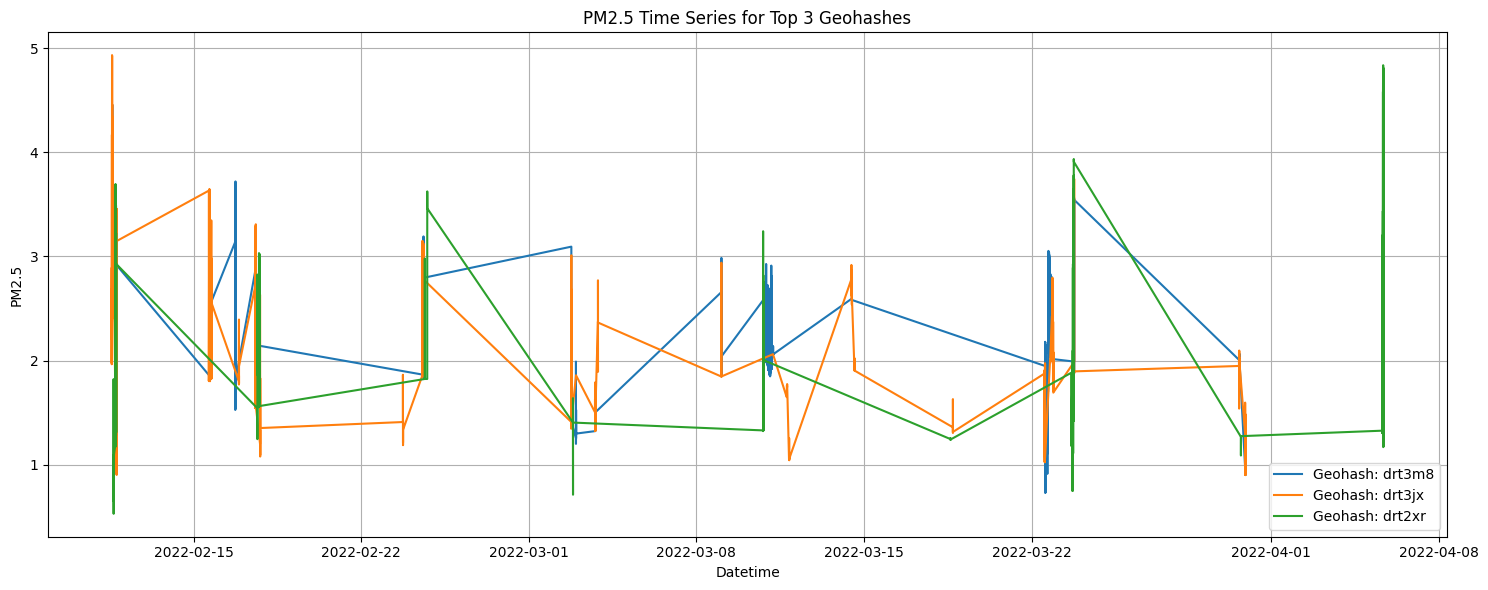

In [3]:
# --- EDA for Boston ---
boston_eda = AirQualityEDA(boston_df, city_name="Boston")
boston_eda.basic_info()
boston_eda.plot_missing_values()
boston_eda.plot_time_series('pm25')
boston_eda.plot_pm25_histogram()
boston_eda.display_geohash_heatmap(map_center=[42.3601, -71.0589])
# --- Geohash-based EDA for Boston ---
print("\n--- Geohash PM2.5 Trends: Boston ---")
boston_eda.plot_pm25_by_geohash(top_n=3)


--- Basic Information: New York ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515917 entries, 0 to 515916
Data columns (total 33 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   SensorID     515917 non-null  object        
 1   time         515917 non-null  int64         
 2   latitude     515917 non-null  float64       
 3   longitude    515917 non-null  float64       
 4   bin0         515917 non-null  int64         
 5   bin1         515917 non-null  int64         
 6   bin2         515917 non-null  int64         
 7   bin3         515917 non-null  int64         
 8   bin4         515917 non-null  int64         
 9   bin5         515917 non-null  int64         
 10  bin6         515917 non-null  int64         
 11  bin7         515917 non-null  int64         
 12  bin8         515917 non-null  int64         
 13  bin9         515917 non-null  int64         
 14  bin10        515917 non-null  int64         
 1

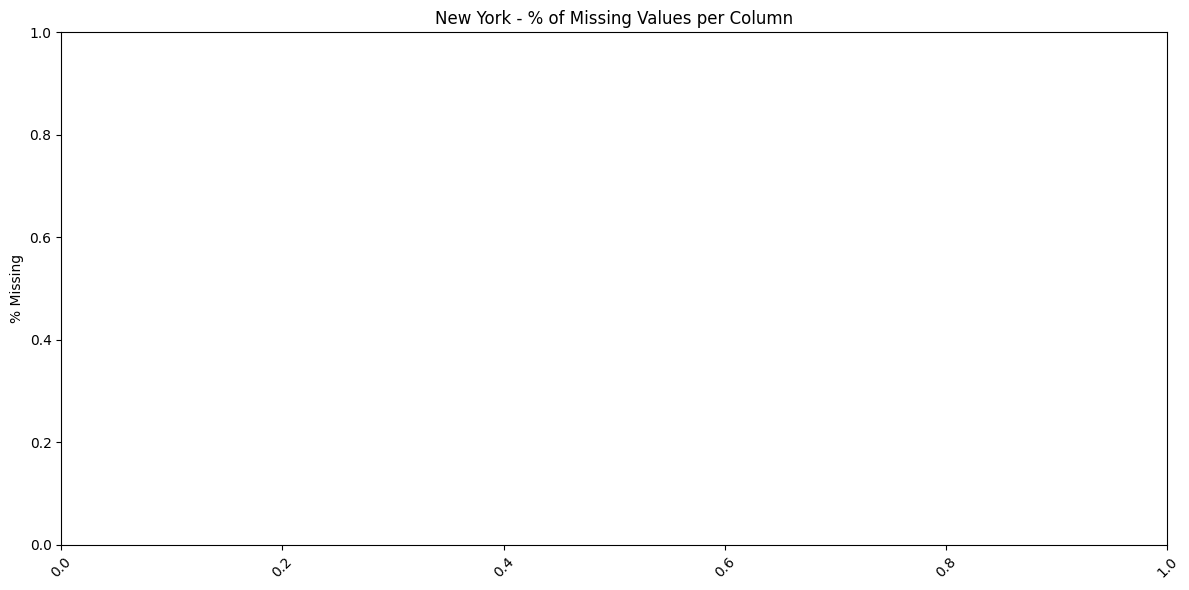

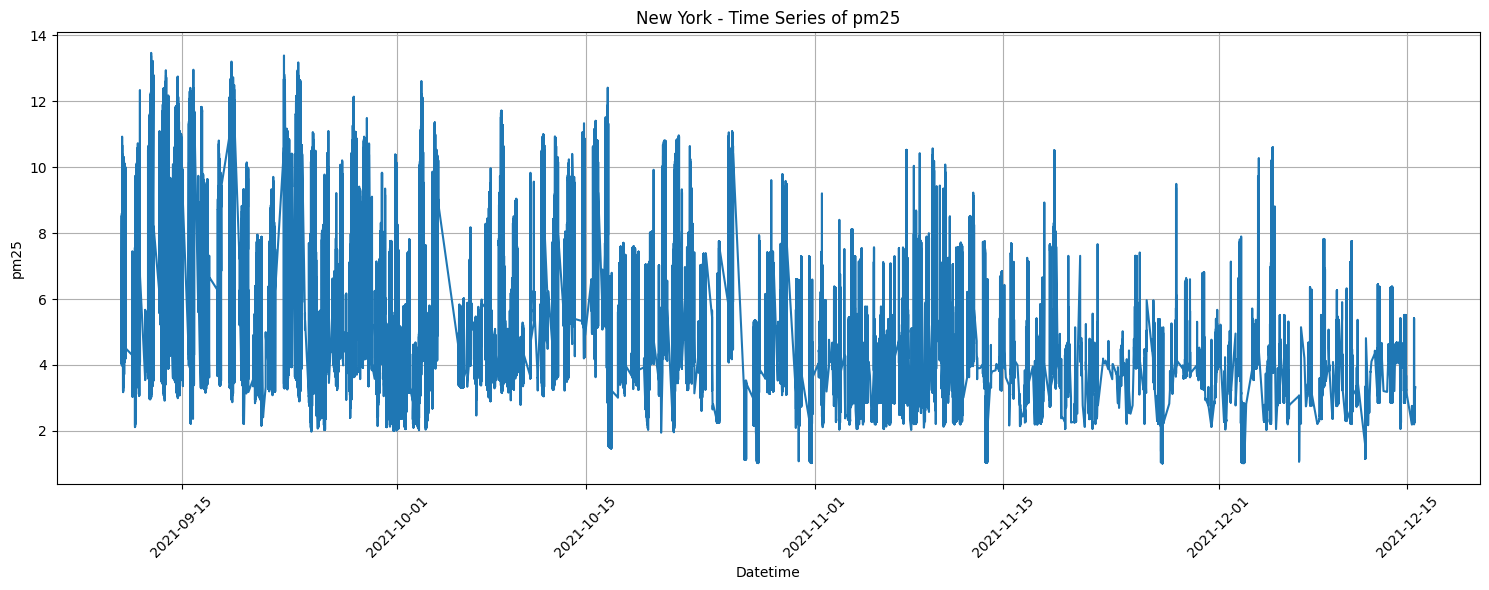

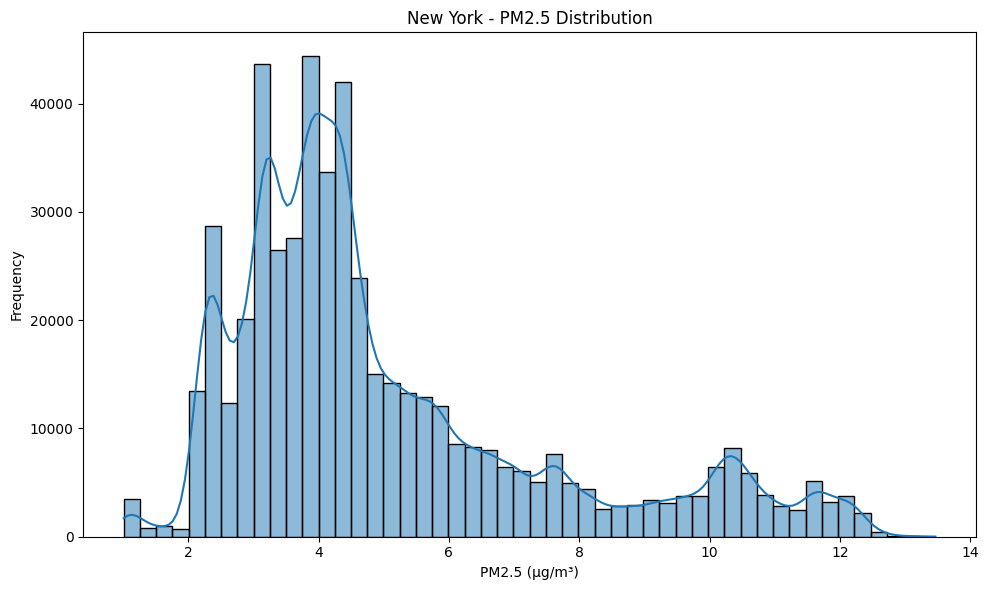


--- Geohash PM2.5 Trends: New York ---


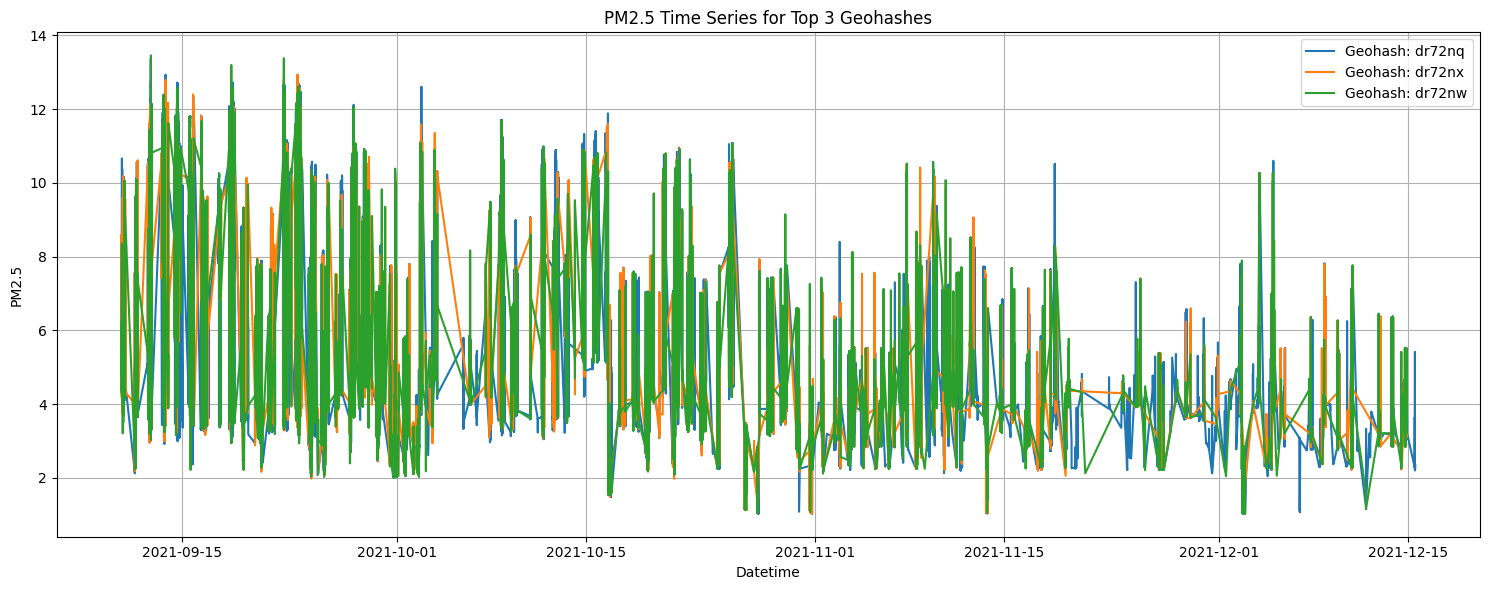

In [4]:
# --- EDA for NewYork ---
newyork_eda = AirQualityEDA(newyork_df, city_name="New York")
newyork_eda.basic_info()
newyork_eda.plot_missing_values()
newyork_eda.plot_time_series('pm25')
newyork_eda.plot_pm25_histogram()
newyork_eda.display_geohash_heatmap(map_center=[40.7128, -74.0060])
# --- Geohash-based EDA for NewYork ---
print("\n--- Geohash PM2.5 Trends: New York ---")
newyork_eda.plot_pm25_by_geohash(top_n=3)

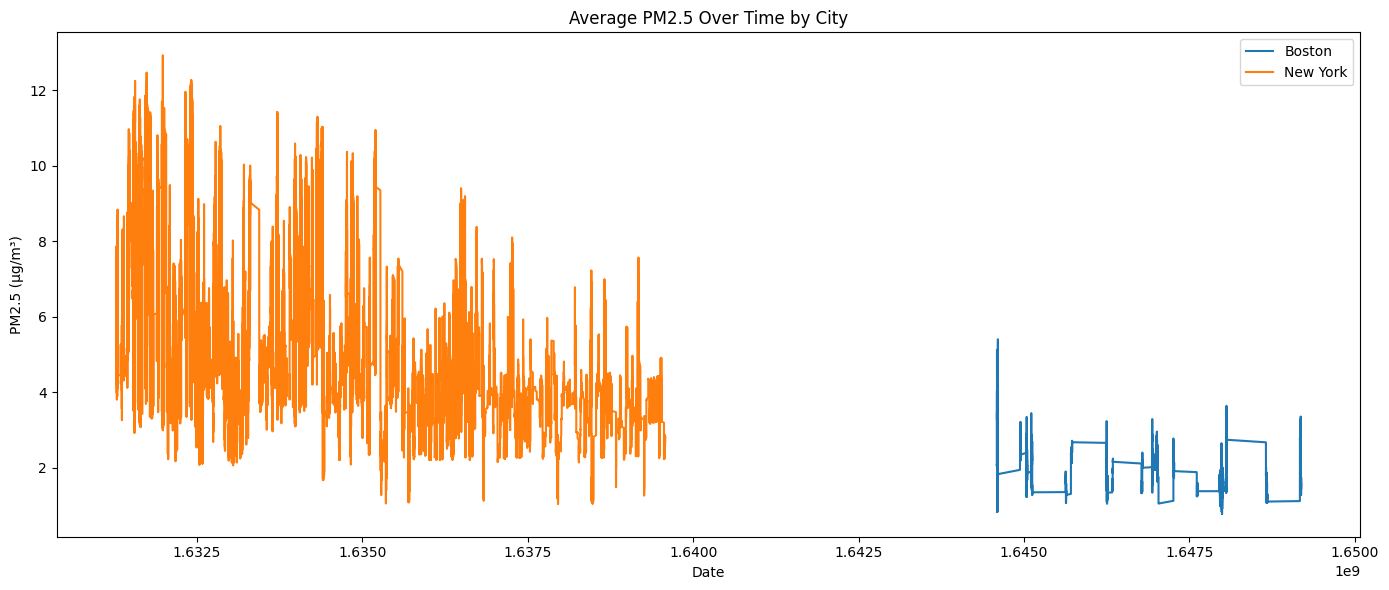

In [5]:
# Cross-city average PM2.5 trends
city_data = {"Boston": boston_df, "New York": newyork_df}
AirQualityEDA.plot_city_comparison(city_data)

Train size: 98214, Test size: 24554
Train size: 98214, Test size: 24554


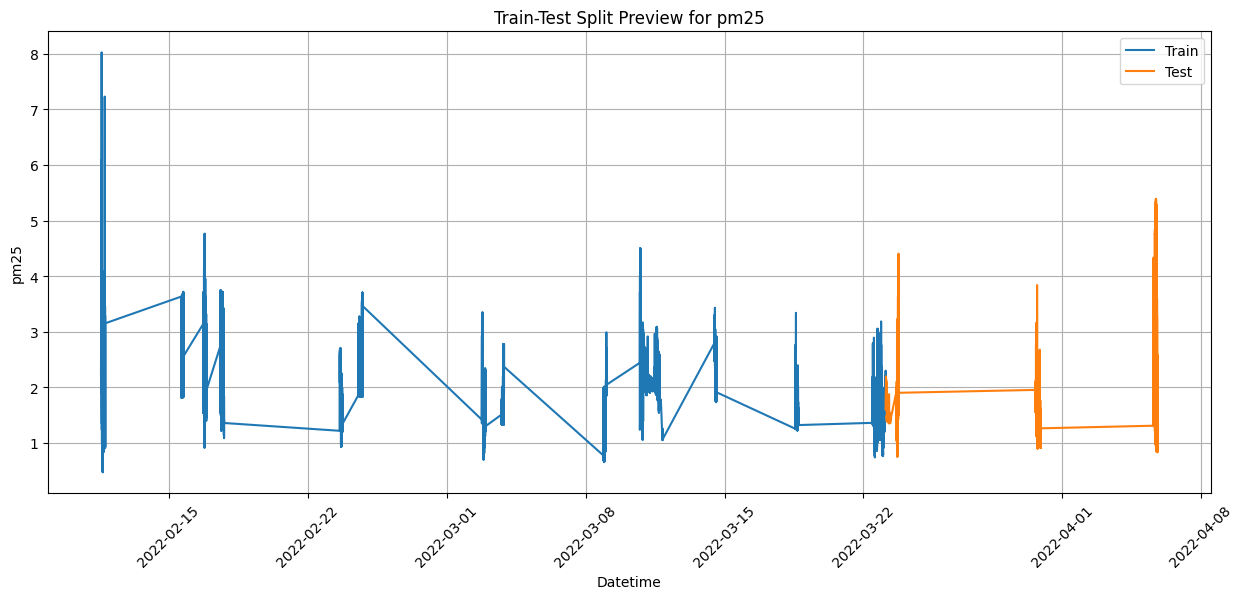

In [6]:
# --- Time Series Split for Boston ---
boston_split = TimeSeriesSplit(boston_df, test_size=0.2)
boston_train, boston_test = boston_split.split()
boston_split.plot_split('pm25')

Train size: 412733, Test size: 103184
Train size: 412733, Test size: 103184


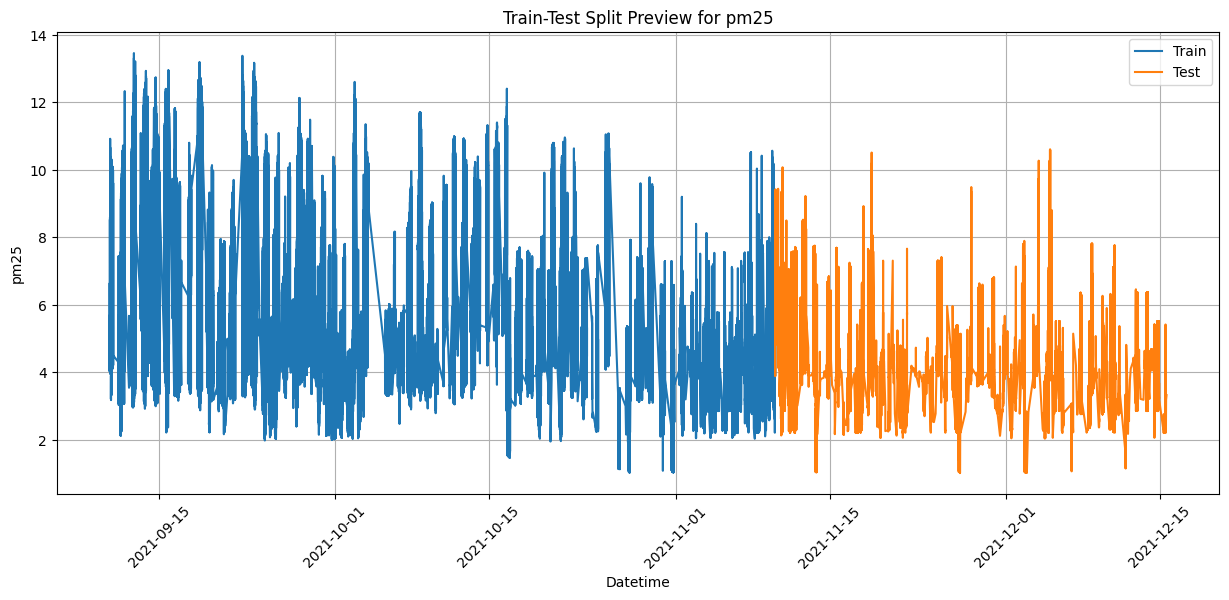

In [7]:
# --- Time Series Split for NewYork ---
newyork_split = TimeSeriesSplit(newyork_df, test_size=0.2)
newyork_train, newyork_test = newyork_split.split()
newyork_split.plot_split('pm25')